# Exploring-Convolutional-Layers-Through-Data-and-Experiments
### Author : Roger Rodriguez

----

## Dataset: Fashion-MNIST

This notebook explores the role of convolutional layers in neural networks. We analyze how architectural decisions impact learning, performance, and inductive bias

### Import the Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models



Load the dataset

In [3]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()


EDA

In [4]:
print("Training samples:", x_train.shape[0])
print("Test samples:", x_test.shape[0])
print("Image shape:", x_train.shape[1:])


Training samples: 60000
Test samples: 10000
Image shape: (28, 28)


Fashion-MNIST consists of 28 × 28 grayscale images belonging to 10 clothing classes.
The data set is balanced and small enough to fit in memory, making it suitable
for exploratory cN experiments

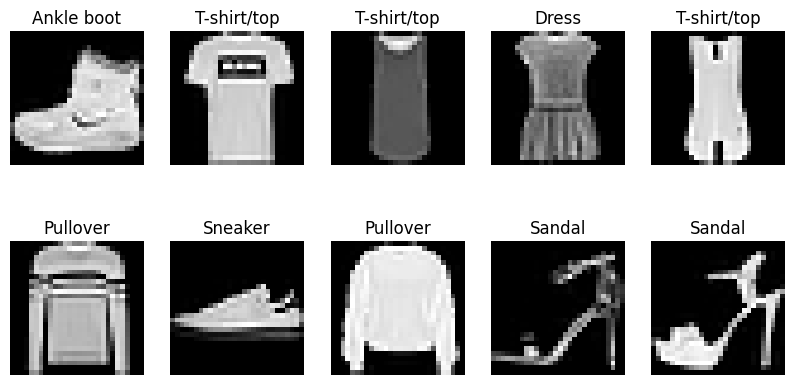

In [ ]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.show()


Visual inspection confirms that class identity depends on local spatial patterns
such as edges, contours and shapes, which motivates the use of convolutional layers

In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train_cnn = x_train[..., np.newaxis]
x_test_cnn = x_test[..., np.newaxis]


### Baseline Model

In [6]:
baseline_model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])


c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


This model treats each pixel independently after flattening it, ignoring
Spatial relationships between neighborin pixels

Training Baseline

In [7]:
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=2
)


Epoch 1/10
1500/1500 - 3s - 2ms/step - accuracy: 0.8188 - loss: 0.5096 - val_accuracy: 0.8392 - val_loss: 0.4434
Epoch 2/10
1500/1500 - 2s - 1ms/step - accuracy: 0.8603 - loss: 0.3835 - val_accuracy: 0.8550 - val_loss: 0.3978
Epoch 3/10
1500/1500 - 2s - 2ms/step - accuracy: 0.8743 - loss: 0.3427 - val_accuracy: 0.8708 - val_loss: 0.3489
Epoch 4/10
1500/1500 - 2s - 2ms/step - accuracy: 0.8821 - loss: 0.3174 - val_accuracy: 0.8793 - val_loss: 0.3282
Epoch 5/10
1500/1500 - 2s - 1ms/step - accuracy: 0.8909 - loss: 0.2955 - val_accuracy: 0.8796 - val_loss: 0.3418
Epoch 6/10
1500/1500 - 2s - 1ms/step - accuracy: 0.8938 - loss: 0.2828 - val_accuracy: 0.8855 - val_loss: 0.3188
Epoch 7/10
1500/1500 - 2s - 2ms/step - accuracy: 0.9001 - loss: 0.2676 - val_accuracy: 0.8885 - val_loss: 0.3112
Epoch 8/10
1500/1500 - 2s - 1ms/step - accuracy: 0.9042 - loss: 0.2571 - val_accuracy: 0.8810 - val_loss: 0.3361
Epoch 9/10
1500/1500 - 2s - 1ms/step - accuracy: 0.9062 - loss: 0.2487 - val_accuracy: 0.8804 - 

Evaluate Baseline

In [8]:
baseline_model.evaluate(x_test, y_test, verbose=0)


[0.3406201899051666, 0.8847000002861023]

Although the baseline achieves reasonable accuracy, it requires a large number
of parameters and lacks robustness to spatial transformations

### CNN Arquitecture Desing 

In [9]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), padding="same", activation="relu",
                  input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])


c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN

In [10]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.fit(
    x_train_cnn, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=2
)


Epoch 1/10
1500/1500 - 11s - 7ms/step - accuracy: 0.8481 - loss: 0.4216 - val_accuracy: 0.8877 - val_loss: 0.3070
Epoch 2/10
1500/1500 - 10s - 7ms/step - accuracy: 0.8991 - loss: 0.2781 - val_accuracy: 0.8963 - val_loss: 0.2845
Epoch 3/10
1500/1500 - 10s - 7ms/step - accuracy: 0.9148 - loss: 0.2313 - val_accuracy: 0.9070 - val_loss: 0.2509
Epoch 4/10
1500/1500 - 10s - 7ms/step - accuracy: 0.9265 - loss: 0.1975 - val_accuracy: 0.9164 - val_loss: 0.2206
Epoch 5/10
1500/1500 - 11s - 7ms/step - accuracy: 0.9367 - loss: 0.1698 - val_accuracy: 0.9173 - val_loss: 0.2236
Epoch 6/10
1500/1500 - 10s - 7ms/step - accuracy: 0.9463 - loss: 0.1458 - val_accuracy: 0.9180 - val_loss: 0.2257
Epoch 7/10
1500/1500 - 10s - 7ms/step - accuracy: 0.9557 - loss: 0.1199 - val_accuracy: 0.9161 - val_loss: 0.2464
Epoch 8/10
1500/1500 - 11s - 7ms/step - accuracy: 0.9635 - loss: 0.0998 - val_accuracy: 0.9193 - val_loss: 0.2391
Epoch 9/10
1500/1500 - 10s - 7ms/step - accuracy: 0.9695 - loss: 0.0826 - val_accuracy: 

Evaluate CNN

In [11]:
cnn_model.evaluate(x_test_cnn, y_test, verbose=0)


[0.291205495595932, 0.9125000238418579]

### Controlled experiment: grain size

CNN With kernel 5x5

In [12]:
cnn_5x5 = models.Sequential([
    layers.Conv2D(32, (5,5), padding="same", activation="relu",
                  input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (5,5), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])


Training and Evaluate

In [13]:
cnn_5x5.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_5x5.fit(
    x_train_cnn, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=2
)

cnn_5x5.evaluate(x_test_cnn, y_test, verbose=0)


Epoch 1/10
1500/1500 - 14s - 9ms/step - accuracy: 0.8450 - loss: 0.4292 - val_accuracy: 0.8894 - val_loss: 0.3096
Epoch 2/10
1500/1500 - 13s - 9ms/step - accuracy: 0.8985 - loss: 0.2788 - val_accuracy: 0.9058 - val_loss: 0.2654
Epoch 3/10
1500/1500 - 14s - 9ms/step - accuracy: 0.9132 - loss: 0.2319 - val_accuracy: 0.9122 - val_loss: 0.2489
Epoch 4/10
1500/1500 - 14s - 9ms/step - accuracy: 0.9255 - loss: 0.1992 - val_accuracy: 0.9140 - val_loss: 0.2329
Epoch 5/10
1500/1500 - 14s - 10ms/step - accuracy: 0.9372 - loss: 0.1706 - val_accuracy: 0.9162 - val_loss: 0.2326
Epoch 6/10
1500/1500 - 14s - 10ms/step - accuracy: 0.9449 - loss: 0.1469 - val_accuracy: 0.9149 - val_loss: 0.2383
Epoch 7/10
1500/1500 - 14s - 10ms/step - accuracy: 0.9540 - loss: 0.1228 - val_accuracy: 0.9144 - val_loss: 0.2637
Epoch 8/10
1500/1500 - 15s - 10ms/step - accuracy: 0.9602 - loss: 0.1044 - val_accuracy: 0.9153 - val_loss: 0.2878
Epoch 9/10
1500/1500 - 15s - 10ms/step - accuracy: 0.9664 - loss: 0.0897 - val_accur

[0.3072339594364166, 0.9186000227928162]

Holding all other factors fixed, larger cores did not improve performance.
This highlights the efficiency of small grains combined with depth

### Interpretation

Convolutional layers outperform fully connected networks because they incorporate
prior assumptions about spatial structure directly into architecture    
This inductive bias reduces parameter counts, improves generalization,
and allows learning of hierarchical features
However, convolution is not appropriate for tabular or non-spatial data,
where locality assumptions are not met

Conclusion :
This study shows that architectural decisions, even simple ones,
have a significant impact on learning behavior
Understanding convolutional layers as inductive biases is key to
designing effective neural networks

EndPoint




In [ ]:
%pip install sagemaker
cnn_model.save("fashion_cnn_model.keras")
# import sagemaker
# from sagemaker.tensorflow import TensorFlowModel
# role = sagemaker.get_execution_role()
# model = TensorFlowModel(
#     model_data="fashion_cnn_model.keras",
#     role=role,
#     framework_version="2.15",
#     sagemaker_session=sagemaker.Session()
# )
# predictor = model.deploy(
#     initial_instance_count=1,
#     instance_type="ml.m5.large"
# )
print("Modelo guardado exitosamente")

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached python_dotenv-1.2.1-py3-none-any.whl.metadata (25 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached filelock-3.24.3-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ------------------------------- -------- 1.0/1.3 MB 5.6 MB/s eta 0:00:01
   -----

ModuleNotFoundError: No module named 'sagemaker.tensorflow'

Prove the endpoint

In [ ]:
import numpy as np

sample = x_test_cnn[0]
sample = np.expand_dims(sample, axis=0)


Send endpoint 

In [ ]:
prediction = predictor.predict(sample)
predicted_class = np.argmax(prediction)

print("Predicted class:", predicted_class)
print("Label:", class_names[predicted_class])
predictor.delete_endpoint()


The trained CNN was deployed as a SageMaker endpoint using the TensorFlowModel abstraction.
The endpoint exposes the model as a managed inference service, enabling predictions on unseen images.
After verification, the endpoint was deleted to avoid unnecessary resource usage